In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
X = dataset.iloc[:, [3,4]].values

In [4]:
from sklearn.cluster import MeanShift
clustering =  MeanShift(bandwidth=15, bin_seeding=True)
y = clustering.fit_predict(X)
y

array([6, 3, 5, 3, 6, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 6, 3, 6, 3, 6, 3,
       5, 3, 5, 3, 6, 3, 6, 3, 5, 3, 5, 3, 5, 3, 5, 3, 6, 3, 6, 3, 6, 3,
       6, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 4, 1, 4, 1, 2, 1, 2, 1,
       4, 1, 2, 1, 2, 1, 2, 1, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1, 2, 1, 4, 1,
       2, 1, 2, 1, 2, 1, 4, 1, 2, 1, 4, 1, 2, 1, 4, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 4, 7, 2, 7, 4, 7, 4, 7, 2, 7, 8, 7, 8, 7, 8, 7, 8, 7,
       8, 7], dtype=int64)

In [5]:
#if you want to see sillhoutte score
from sklearn.metrics import silhouette_score
score = silhouette_score(X, y)
print("Silhouette Score: ", score)

Silhouette Score:  0.48214607657756936


In [6]:
supervised = dataset
supervised["Cluster_group"] = y
supervised.to_csv("MShift_cluster.csv", index=False)

C:\Anaconda3\envs\aiml\lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


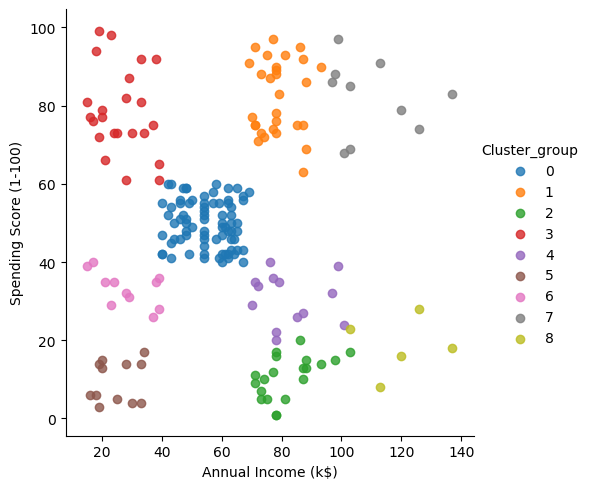

In [7]:
import seaborn as sns#seaborn library is used for graphyical purpose
facet = sns.lmplot(data=supervised, x=supervised.columns[3] , y=supervised.columns[4], hue = supervised.columns[5], fit_reg = False, legend=True, legend_out = True)